In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Configurations (unchanged from original)
IMAGE_SIZE = 224
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
K_NEIGHBORS = 2
BATCH_SIZE = 32
NUM_EPOCHS = 5
PATIENCE = 10
NUM_WORKERS = min(4, os.cpu_count() or 1)

# Paths (unchanged)
TRAIN_DIR = "/content/drive/MyDrive/Preprocessed/train"
TEST_DIR = "/content/drive/MyDrive/Preprocessed/valid"

# 1. CNN-LSTM Feature Extractor
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.lstm = nn.LSTM(input_size=128*4*4, hidden_size=512, batch_first=True)
        self.fc = nn.Linear(512, 64)
        
        # Initialize weights
        self.apply(self.init_weights)
    
    @staticmethod
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.cnn(x)
        batch_size = x.size(0)
        x = x.view(batch_size, 1, -1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Use last hidden state instead of mean
        return self.fc(x)

# 2. GNN Classifier
class FaceGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(FaceGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        
        # Initialize weights
        self.apply(self.init_weights)
    
    @staticmethod
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)  # Reduced dropout
        x = self.conv2(x, edge_index)
        return self.classifier(x)

# 3. Graph Construction
def build_knn_graph(features, k=K_NEIGHBORS):
    # Normalize features for better k-NN
    features = F.normalize(features, p=2, dim=1)
    features_np = features.detach().cpu().numpy()
    
    # Standard sklearn k-NN
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(features_np)
    _, indices = nn.kneighbors(features_np)
    
    # # Optional: Faster k-NN with faiss (uncomment to use)
    # index = faiss.IndexFlatL2(features_np.shape[1])
    # index.add(features_np)
    # _, indices = index.search(features_np, k)
    
    edges = []
    for i in range(len(indices)):
        for j in indices[i]:
            if i != j:
                edges.append([i, j])
                edges.append([j, i])  # Ensure undirected graph
    
    return torch.tensor(edges, dtype=torch.long).t().contiguous().to(DEVICE)

# 4. Data Loading
class FaceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Warning: Skipping corrupted image {self.image_paths[idx]}: {e}")
            return None

def custom_collate_fn(batch):
    # Filter out None items (corrupted images)
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

def load_data(data_dir):
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    image_paths = []
    labels = []
    
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        img_files = [f for f in sorted(os.listdir(class_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if not img_files:
            print(f"Warning: No valid images in class {class_name}")
            continue
        for img_name in img_files:
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_to_idx[class_name])
    
    if not image_paths:
        raise ValueError("No valid images found in the dataset")
    
    return image_paths, labels, class_to_idx

# Modified Training Pipeline to Track Metrics
def train(feature_extractor, gnn, train_loader, optimizer, criterion, scaler):
    feature_extractor.train()
    gnn.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        if batch is None:
            continue
        images, labels = batch
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            features = feature_extractor(images)
            edge_index = build_knn_graph(features)
            logits = gnn(features, edge_index)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        num_batches += 1
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / max(num_batches, 1), accuracy

def evaluate(feature_extractor, gnn, loader):
    feature_extractor.eval()
    gnn.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            if batch is None:
                continue
            images, labels = batch
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            with torch.amp.autocast('cuda'):
                features = feature_extractor(images)
                edge_index = build_knn_graph(features)
                logits = gnn(features, edge_index)
                loss = criterion(logits, labels)
                preds = logits.argmax(dim=1)
            
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            num_batches += 1
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    avg_loss = total_loss / max(num_batches, 1)
    
    return accuracy, precision, recall, all_labels, all_preds, avg_loss

# Plotting Functions
def plot_confusion_matrix(true_labels, pred_labels, class_names, save_path="confusion_matrix.png"):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_training_curves(train_losses, train_accs, val_losses, val_accs, save_path="training_curves.png"):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Load data
    try:
        train_paths, train_labels, class_to_idx = load_data(TRAIN_DIR)
        test_paths, test_labels, _ = load_data(TEST_DIR)
    except ValueError as e:
        print(f"Error: {e}")
        exit(1)
    
    # Create transforms and dataloaders (unchanged)
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    train_dataset = FaceDataset(train_paths, train_labels, train_transform)
    test_dataset = FaceDataset(test_paths, test_labels, test_transform)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=NUM_WORKERS,
        collate_fn=custom_collate_fn
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=NUM_WORKERS,
        collate_fn=custom_collate_fn
    )
    
    # Initialize models
    feature_extractor = CNNLSTM().to(DEVICE)
    gnn = FaceGNN(input_dim=64, hidden_dim=256, num_classes=len(class_to_idx)).to(DEVICE)
    
    # Optimizer, scheduler, scaler, and loss
    optimizer = torch.optim.Adam([
        {'params': feature_extractor.parameters()},
        {'params': gnn.parameters()}
    ], lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    scaler = GradScaler()
    criterion = nn.CrossEntropyLoss()
    
    # Training loop with early stopping and metric tracking
    best_accuracy = 0
    patience_counter = 0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train(feature_extractor, gnn, train_loader, optimizer, criterion, scaler)
        val_acc, val_precision, val_recall, val_labels, val_preds, val_loss = evaluate(feature_extractor, gnn, test_loader)
        
        # Store metrics
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
        
        # Update scheduler
        scheduler.step(val_acc)
        
        # Save best model
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            patience_counter = 0
            torch.save({
                'feature_extractor': feature_extractor.state_dict(),
                'gnn': gnn.state_dict(),
                'class_to_idx': class_to_idx
            }, "best_model.pth")
            print("Saved new best model")
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered after {epoch} epochs")
            break
    
    print(f"\nTraining complete! Best Validation Accuracy: {best_accuracy:.4f}")
    
    # Plot confusion matrix
    class_names = [k for k, v in sorted(class_to_idx.items(), key=lambda x: x[1])]
    plot_confusion_matrix(val_labels, val_preds, class_names)
    
    # Plot training and validation curves
    plot_training_curves(train_losses, train_accs, val_losses, val_accs)

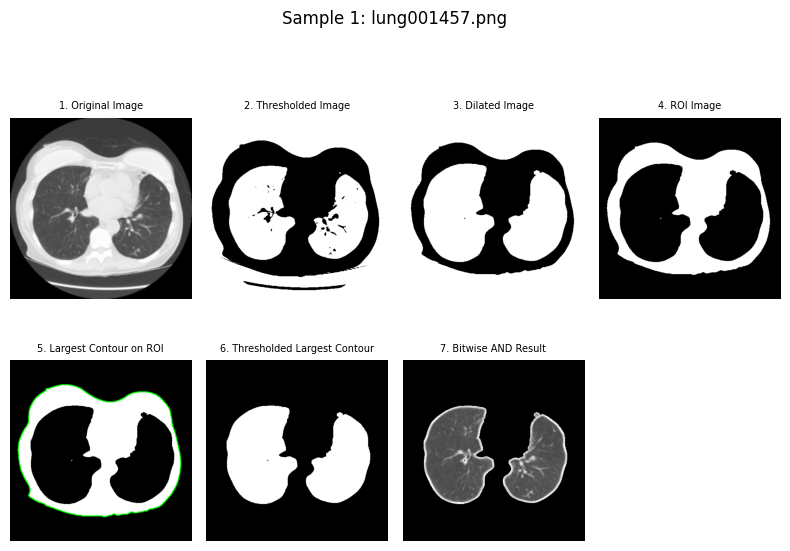

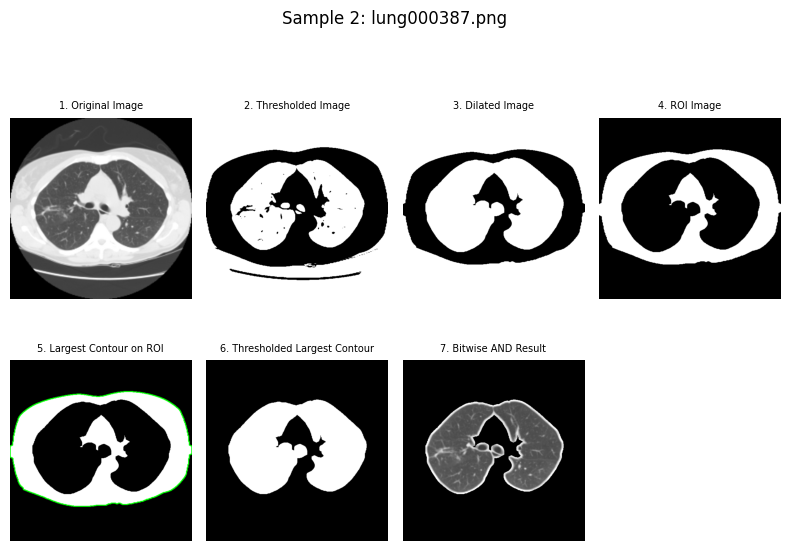

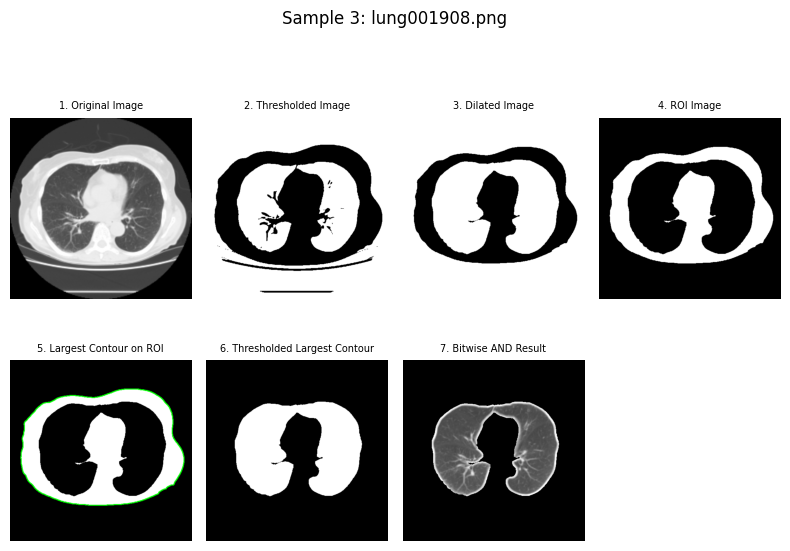

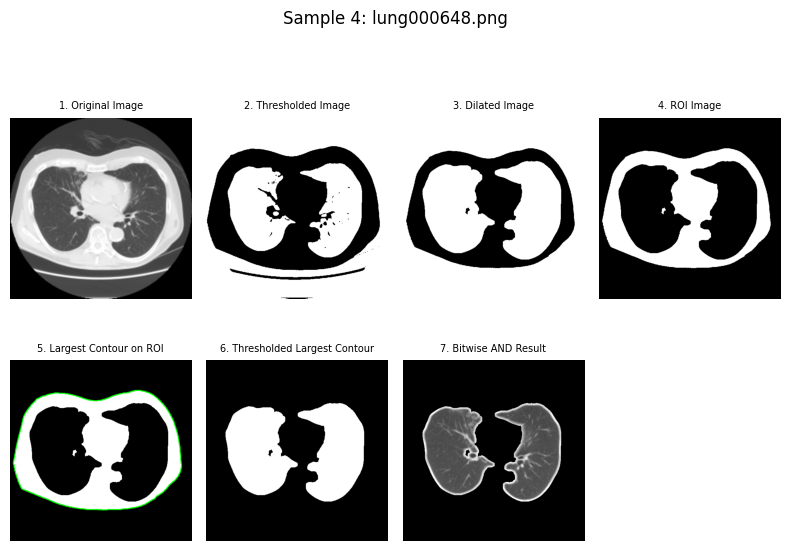

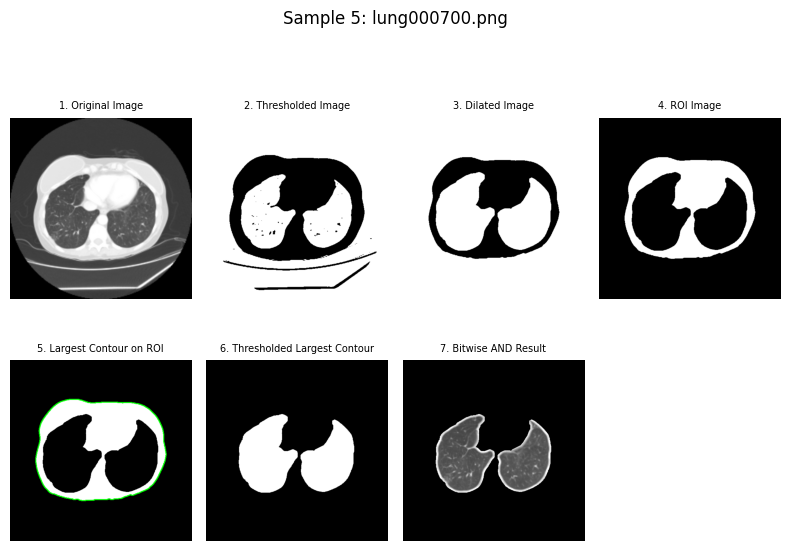

In [15]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

def extract_clean_lung_roi(image_path):
    # Step 1: Read and resize image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original_image is None:
        raise ValueError(f"Failed to load image: {image_path}")
    original_image = cv2.resize(original_image, (512, 512))
    original_image_copy = original_image.copy()

    # Step 2: Binary threshold
    _, thresholded_image = cv2.threshold(original_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresholded_image = cv2.bitwise_not(thresholded_image)  # Invert so lungs are white
    thresholded_image_copy = thresholded_image.copy()

    # Step 3: Dilation
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated_image = cv2.dilate(thresholded_image, dilation_kernel, iterations=3)
    dilated_image_copy = dilated_image.copy()

    _, roi_threshold = cv2.threshold(dilated_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    roi_image = cv2.bitwise_not(dilated_image)  # Invert so lungs are white (ROI)

    # Contour detection on dilated image (for logging only)
    contours, _ = cv2.findContours(dilated_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for index, contour in enumerate(contours[:10]):  # Check top 10 contours
        x, y, width, height = cv2.boundingRect(contour)
        contour_area = cv2.contourArea(contour)

    # Step 4: Find largest contour in roi_image (ROI)
    roi_contours, _ = cv2.findContours(roi_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if roi_contours:
        largest_contour = max(roi_contours, key=cv2.contourArea)
        largest_contour_area = cv2.contourArea(largest_contour)
        
        # Create an image to display the largest contour
        contour_display_image = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(contour_display_image, [largest_contour], -1, (0, 255, 0), 2)  # Green contour
        
        # Step 5: Create mask for largest contour and apply thresholding
        largest_contour_mask = np.zeros_like(roi_image)
        cv2.drawContours(largest_contour_mask, [largest_contour], -1, 255, -1)  # Fill largest contour
        # Apply mask to roi_image to isolate the contour's region
        masked_contour_region = cv2.bitwise_and(roi_image, roi_image, mask=largest_contour_mask)
        # Invert the region (white to black, black to white)
        inverted_contour_region = cv2.bitwise_not(masked_contour_region)
        # Combine with the original ROI image, keeping non-contour areas unchanged
        thresholded_contour_image = roi_image.copy()
        thresholded_contour_image[largest_contour_mask == 255] = inverted_contour_region[largest_contour_mask == 255]
    else:
        print("No contours found in ROI")
        contour_display_image = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2BGR)  # Fallback
        thresholded_contour_image = roi_image.copy()  # Fallback: no thresholding

    # Step 6: Bitwise AND between thresholded_contour_image and original_image
    bitwise_and_image = cv2.bitwise_and(original_image, thresholded_contour_image)

    # Return images and intermediates
    return (
        original_image,
        {
            "1. Original Image": original_image_copy,
            "2. Thresholded Image": thresholded_image_copy,
            "3. Dilated Image": dilated_image_copy,
            "4. ROI Image": roi_image,
            "5. Largest Contour on ROI": contour_display_image,
            "6. Thresholded Largest Contour": thresholded_contour_image,
            "7. Bitwise AND Result": bitwise_and_image,
        }
    )

def show_random_lung_samples(image_folder_path, num_samples=5):
    image_extensions = (".png", ".jpg", ".jpeg")
    image_paths = [os.path.join(image_folder_path, filename) for filename in os.listdir(image_folder_path) if filename.lower().endswith(image_extensions)]

    if not image_paths:
        raise ValueError(f"No images found in {image_folder_path}")

    random.shuffle(image_paths)
    selected_image_paths = image_paths[:min(num_samples, len(image_paths))]

    for index, selected_image_path in enumerate(selected_image_paths):
        try:
            processed_image, intermediate_images = extract_clean_lung_roi(selected_image_path)

            # Display all steps
            plt.figure(figsize=(8, 6))
            plt.suptitle(f"Sample {index+1}: {os.path.basename(selected_image_path)}", fontsize=12)

            # Plot each intermediate step
            for subplot_index, (step_name, step_image) in enumerate(intermediate_images.items(), 1):
                plt.subplot(2, 4, subplot_index)
                if step_name == "5. Largest Contour on ROI":
                    plt.imshow(step_image)  # Show in color for contour
                else:
                    plt.imshow(step_image, cmap='gray')
                plt.title(step_name, fontsize=7)
                plt.axis('off')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        except Exception as error:
            print(f"Error processing {os.path.basename(selected_image_path)}: {str(error)}")

# 🔽 USAGE
image_folder_path = "/home/shanin/Desktop/SHANIN/MAIN/ALL_CODE/CNN-GNN/radiology_ai/CT/lung/Bronchiectasis"
show_random_lung_samples(image_folder_path, num_samples=5)

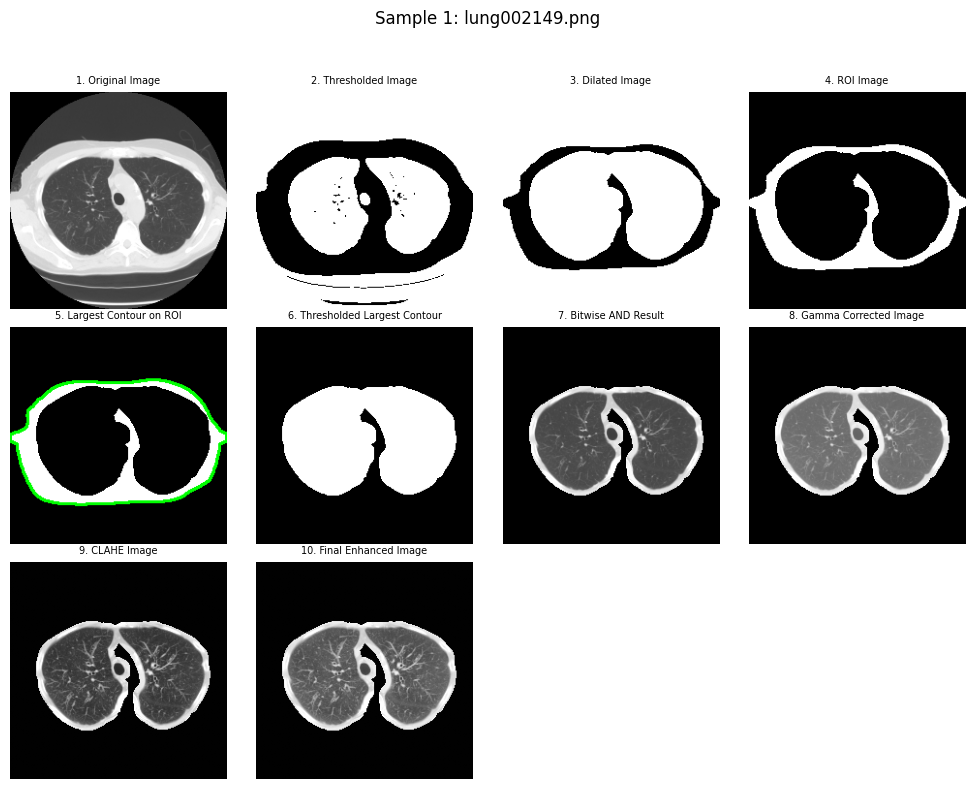

In [1]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

def apply_gamma_correction(image, gamma=1.0):
    """Apply gamma correction to the image."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

def apply_clahe(image):
    """Apply CLAHE to the image."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

def extract_clean_lung_roi(image_path):
    # Step 1: Read and resize image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original_image is None:
        raise ValueError(f"Failed to load image: {image_path}")
    # original_image = cv2.resize(original_image, (512, 512))
    original_image_copy = original_image.copy()

    # Step 2: Binary threshold
    _, thresholded_image = cv2.threshold(original_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresholded_image = cv2.bitwise_not(thresholded_image)  # Invert so lungs are white
    thresholded_image_copy = thresholded_image.copy()

    # Step 3: Dilation
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated_image = cv2.dilate(thresholded_image, dilation_kernel, iterations=3)
    dilated_image_copy = dilated_image.copy()

    _, roi_threshold = cv2.threshold(dilated_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    roi_image = cv2.bitwise_not(dilated_image)  # Invert so lungs are white (ROI)

    # Contour detection on dilated image (for logging only)
    contours, _ = cv2.findContours(dilated_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for index, contour in enumerate(contours[:10]):  # Check top 10 contours
        x, y, width, height = cv2.boundingRect(contour)
        contour_area = cv2.contourArea(contour)

    # Step 4: Find largest contour in roi_image (ROI)
    roi_contours, _ = cv2.findContours(roi_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if roi_contours:
        largest_contour = max(roi_contours, key=cv2.contourArea)
        largest_contour_area = cv2.contourArea(largest_contour)
        
        # Create an image to display the largest contour
        contour_display_image = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(contour_display_image, [largest_contour], -1, (0, 255, 0), 2)  # Green contour
        
        # Step 5: Create mask for largest contour and apply thresholding
        largest_contour_mask = np.zeros_like(roi_image)
        cv2.drawContours(largest_contour_mask, [largest_contour], -1, 255, -1)  # Fill largest contour
        # Apply mask to roi_image to isolate the contour's region
        masked_contour_region = cv2.bitwise_and(roi_image, roi_image, mask=largest_contour_mask)
        # Invert the region (white to black, black to white)
        inverted_contour_region = cv2.bitwise_not(masked_contour_region)
        # Combine with the original ROI image, keeping non-contour areas unchanged
        thresholded_contour_image = roi_image.copy()
        thresholded_contour_image[largest_contour_mask == 255] = inverted_contour_region[largest_contour_mask == 255]
    else:
        print("No contours found in ROI")
        contour_display_image = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2BGR)  # Fallback
        thresholded_contour_image = roi_image.copy()  # Fallback: no thresholding

    # Step 6: Bitwise AND between thresholded_contour_image and original_image
    bitwise_and_image = cv2.bitwise_and(original_image, thresholded_contour_image)

    # Step 7: Apply gamma correction and CLAHE to bitwise_and_image
    gamma_corrected_image = apply_gamma_correction(bitwise_and_image, gamma=1.5)  # Adjust gamma as needed
    clahe_image = apply_clahe(bitwise_and_image)
    # Combine gamma correction and CLAHE for final image
    final_enhanced_image = apply_clahe(gamma_corrected_image)

    # Return images and intermediates
    return (
        original_image,
        {
            "1. Original Image": original_image_copy,
            "2. Thresholded Image": thresholded_image_copy,
            "3. Dilated Image": dilated_image_copy,
            "4. ROI Image": roi_image,
            "5. Largest Contour on ROI": contour_display_image,
            "6. Thresholded Largest Contour": thresholded_contour_image,
            "7. Bitwise AND Result": bitwise_and_image,
            "8. Gamma Corrected Image": gamma_corrected_image,
            "9. CLAHE Image": clahe_image,
            "10. Final Enhanced Image": final_enhanced_image,
        }
    )

def show_random_lung_samples(image_folder_path, num_samples=5):
    image_extensions = (".png", ".jpg", ".jpeg")
    image_paths = [os.path.join(image_folder_path, filename) for filename in os.listdir(image_folder_path) if filename.lower().endswith(image_extensions)]

    if not image_paths:
        raise ValueError(f"No images found in {image_folder_path}")

    random.shuffle(image_paths)
    selected_image_paths = image_paths[:min(num_samples, len(image_paths))]

    for index, selected_image_path in enumerate(selected_image_paths):
        try:
            processed_image, intermediate_images = extract_clean_lung_roi(selected_image_path)

            # Display all steps
            plt.figure(figsize=(10, 8))
            plt.suptitle(f"Sample {index+1}: {os.path.basename(selected_image_path)}", fontsize=12)

            # Plot each intermediate step
            for subplot_index, (step_name, step_image) in enumerate(intermediate_images.items(), 1):
                plt.subplot(3, 4, subplot_index)
                if step_name == "5. Largest Contour on ROI":
                    plt.imshow(step_image)  # Show in color for contour
                else:
                    plt.imshow(step_image, cmap='gray')
                plt.title(step_name, fontsize=7)
                plt.axis('off')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        except Exception as error:
            print(f"Error processing {os.path.basename(selected_image_path)}: {str(error)}")

# 🔽 USAGE
image_folder_path = "/home/shanin/Desktop/SHANIN/MAIN/ALL_CODE/CNN-GNN/radiology_ai/CT/lung/Bronchiectasis"
show_random_lung_samples(image_folder_path, num_samples=1)